In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from grid_refinement import GridRefinement, visualize_grids

# Настройка отображения
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline


In [18]:
# Параметры исходной сетки
N_x = 20  # Количество ячеек по X
N_y = 20  # Количество ячеек по Y
x_min, x_max = 0, 10  # Границы по X
y_min, y_max = 0, 10  # Границы по Y

# Создание объекта для работы с сеткой
grid = GridRefinement([], [], np.array([[0]]))

# Генерация тестовой сетки
X_orig, Y_orig, Z_orig = grid.generate_test_grid(
    N_x=N_x, N_y=N_y, 
    x_min=x_min, x_max=x_max, 
    y_min=y_min, y_max=y_max
)

print("Исходная сетка:")
print(f"  Размерность: {N_x} x {N_y} ячеек")
print(f"  Узлов: {len(X_orig)} x {len(Y_orig)}")
# Выводим только примеры координат для сетки 20x20
if len(X_orig) > 10:
    print(f"  X координаты (примеры): {X_orig[1:6]} ... {X_orig[-2:]}")
    print(f"  Y координаты (примеры): {Y_orig[1:6]} ... {Y_orig[-2:]}")
else:
    print(f"  X координаты: {X_orig}")
    print(f"  Y координаты: {Y_orig}")
print(f"  Высоты: min = {Z_orig.min():.2f} м, max = {Z_orig.max():.2f} м")


Исходная сетка:
  Размерность: 20 x 20 ячеек
  Узлов: 21 x 21
  X координаты (примеры): [0.49308678 1.03238443 1.57615149 1.98829233 2.48829315] ... [ 9.42938481 10.        ]
  Y координаты (примеры): [0.50337641 0.92876259 1.47278086 2.00554613 2.44245032] ... [ 9.53692333 10.        ]
  Высоты: min = 2.18 м, max = 9.36 м


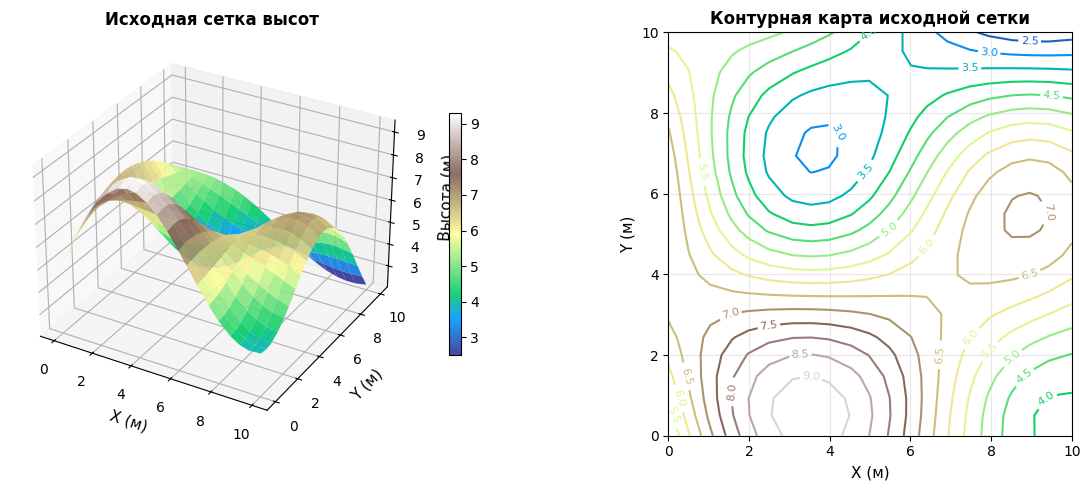

In [19]:
fig = plt.figure(figsize=(14, 5))

# 3D поверхность
ax1 = fig.add_subplot(121, projection='3d')
X_grid, Y_grid = np.meshgrid(X_orig, Y_orig, indexing='ij')
surf = ax1.plot_surface(X_grid, Y_grid, Z_orig, cmap=cm.terrain, 
                        alpha=0.9, linewidth=0.5, antialiased=True)
ax1.set_xlabel('X (м)', fontsize=11)
ax1.set_ylabel('Y (м)', fontsize=11)
ax1.set_zlabel('Высота (м)', fontsize=11)
ax1.set_title('Исходная сетка высот', fontsize=12, fontweight='bold')
plt.colorbar(surf, ax=ax1, shrink=0.6, aspect=20)

# 2D контурная карта
ax2 = fig.add_subplot(122)
contour = ax2.contour(X_grid, Y_grid, Z_orig, levels=15, cmap=cm.terrain)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('X (м)', fontsize=11)
ax2.set_ylabel('Y (м)', fontsize=11)
ax2.set_title('Контурная карта исходной сетки', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()


In [20]:
X_ref, Y_ref, Z_ref = grid.refine_grid_midpoints()

print(f"Сгущенная сетка (добавление середин):")
print(f"  Размерность: {len(X_ref)-1} x {len(Y_ref)-1} ячеек")
print(f"  Узлов: {len(X_ref)} x {len(Y_ref)}")
# Выводим только примеры координат для сгущенной сетки
if len(X_ref) > 10:
    print(f"  X координаты (примеры): {X_ref[1:6]} ... {X_ref[-2:]}")
    print(f"  Y координаты (примеры): {Y_ref[1:6]} ... {Y_ref[-2:]}")
else:
    print(f"  X координаты: {X_ref}")
    print(f"  Y координаты: {Y_ref}")
print(f"  Высоты: min = {Z_ref.min():.2f} м, max = {Z_ref.max():.2f} м")
print(f"\nКоэффициент увеличения узлов: {len(X_ref)/len(X_orig):.1f} x {len(Y_ref)/len(Y_orig):.1f}")


Сгущенная сетка (добавление середин):
  Размерность: 40 x 40 ячеек
  Узлов: 41 x 41
  X координаты (примеры): [0.24654339 0.49308678 0.76273561 1.03238443 1.30426796] ... [ 9.71469241 10.        ]
  Y координаты (примеры): [0.25168821 0.50337641 0.7160695  0.92876259 1.20077173] ... [ 9.76846166 10.        ]
  Высоты: min = 2.18 м, max = 9.36 м

Коэффициент увеличения узлов: 2.0 x 2.0
